# Emotion Recognition from Speech

A concise, end-to-end notebook for training and evaluating a convolutional neural network (CNN) that recognizes emotions from short speech audio clips using MFCC features.

This notebook is designed to be self-contained and reproducible. It walks through:
- Data layout and assumptions
- Feature engineering (MFCCs)
- Model architecture
- Training and evaluation
- Inference on new audio files

If you are here to quickly run the model, see the Usage section near the end.

## Table of Contents
1. Dataset and Project Structure
2. Environment and Reproducibility
3. Feature Extraction
4. Model Architecture
5. Training
6. Evaluation Metrics
7. Prediction and Inference


## Dataset and Project Structure

- **Expected directory layout**:
  - `data/` – training data organized by emotion label
    - `happy/`, `angry/`, `sad/` (one folder per class)
  - `test/` – optional examples for quick inference demos
  - `src/` – original Python modules (now consolidated here)
  - `emotion_cnn.h5` – saved Keras model (created after training)

- **Audio format**: `.wav` mono files sampled at their native sampling rate.
- **Labels**: derived from folder names; maintain consistent class ordering between training and inference.

If your folders differ, update the `emotions = [...]` list in the training cell accordingly.


## Environment and Reproducibility

- **Python**: 3.8–3.11
- **Key packages**: `tensorflow`, `librosa`, `numpy`, `scikit-learn`, `soundfile`
- **Installation**:
  - In this notebook, the first code cell installs dependencies from `requirements.txt` and ensures audio backends are present.
- **Reproducibility**:
  - Random seeds are set for NumPy and Python.
  - For fully deterministic GPU runs, additional framework-specific flags may be required and are not covered here.

If you encounter import errors (e.g., `ModuleNotFoundError: librosa`), re-run the first setup cell before running imports.


## Methodology

- **Feature Engineering (MFCCs)**:
  - Extract 40 Mel-frequency cepstral coefficients (MFCCs) per frame using `librosa`.
  - Fixed-length time axis via zero-padding or truncation to `max_len` frames to form a consistent tensor shape.

- **Model Architecture**:
  - Compact 2D CNN over the MFCC time-frequency map.
  - Layers: Conv2D → MaxPool → Dropout → Flatten → Dense → Dropout → Softmax.
  - Optimizer: Adam; Loss: Sparse Categorical Cross-Entropy; Metric: Accuracy.

- **Training Protocol**:
  - Stratified train/validation split (default 80/20).
  - Batch size 32, 30 epochs by default.
  - You may enable early stopping or learning-rate scheduling for longer runs.

- **Class Mapping**:
  - Class indices correspond to the order of `emotions = ['happy', 'angry', 'sad']`.
  - Keep this ordering consistent when training and during inference.


## Evaluation and Usage

- **Training**:
  1. Run the setup cell to install dependencies.
  2. Run the imports cell.
  3. Execute the feature extraction and training cells. A model file `emotion_cnn.h5` will be saved in the project root.

- **Validation**:
  - The training cell prints validation accuracy per epoch. Consider adding a confusion matrix for deeper insight if needed.

- **Inference**:
  - Use the provided prediction helper with a `.wav` file path, for example:
    - `test/happy/OAF_five_happy.wav`
  - Ensure the same `emotions` ordering is used as during training.

- **Tips**:
  - Normalize input loudness across files to reduce variance.
  - Ensure consistent sampling rates; `librosa.load` handles resampling if a target `sr` is specified.
  - For production, export the model along with the feature-extraction parameters.


### Feature Extraction

This section defines utilities to compute MFCC features from `.wav` files and to assemble datasets from a labeled folder structure.

- `extract_mfcc(path, n_mfcc=40, max_len=174)`: loads audio, computes MFCCs, and pads/truncates to a fixed length for batching.
- `load_data(data_dir, emotions, ...)`: iterates per-class folders to build `X` (MFCC tensors) and `y` (integer labels).

Notes:
- Keep `n_mfcc` and `max_len` consistent between training and inference.
- For large datasets, consider streaming/batching rather than loading everything into memory.

In [ ]:
# Setup: install core dependencies (idempotent)
%pip install -q --disable-pip-version-check -r requirements.txt
%pip install -q --disable-pip-version-check soundfile seaborn

import sys
print('Python:', sys.version)
print('Executable:', sys.executable)


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Python: 3.13.1 (tags/v3.13.1:0671451, Dec  3 2024, 19:06:28) [MSC v.1942 64 bit (AMD64)]
Executable: c:\Users\PC\AppData\Local\Programs\Python\Python313\python.exe


In [57]:
# Imports and global config
import os
import random
import numpy as np
import librosa
from typing import List, Tuple

random.seed(42)
np.random.seed(42)


In [ ]:
import librosa
import numpy as np
import os

def extract_mfcc(file_path, n_mfcc=40, max_len=174):
    y, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    if mfcc.shape[1] < max_len:
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    return mfcc

def load_data(data_dir, emotions, n_mfcc=40, max_len=174):
    X, y = [], []
    for idx, emotion in enumerate(emotions):
        emotion_dir = os.path.join(data_dir, emotion)
        for file in os.listdir(emotion_dir):
            if file.endswith('.wav'):
                mfcc = extract_mfcc(os.path.join(emotion_dir, file), n_mfcc, max_len)
                X.append(mfcc)
                y.append(idx)
    return np.array(X), np.array(y) 

### Model Architecture

We construct a compact 2D CNN that operates on MFCC spectrograms.

- Input shape: `(n_mfcc, max_len, 1)` where the last dimension is the channel.
- Stack: Conv2D → MaxPooling2D → Dropout → Flatten → Dense → Dropout → Softmax.
- Compiled with Adam optimizer and sparse categorical cross-entropy loss.

This baseline is intentionally small for speed; you can deepen the network or add regularization for larger datasets.

In [ ]:
# Training using local functions
from sklearn.model_selection import train_test_split

# Define emotions matching your folders in data/
emotions = ['happy', 'angry', 'sad']

# Load data via local `load_data`
X, y = load_data('data', emotions)
X = X[..., np.newaxis]  # add channel dim

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Build model via local `build_cnn`
input_shape = X_train.shape[1:]
num_classes = len(emotions)
model = build_cnn(input_shape, num_classes)

# Train
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Save
model.save('emotion_cnn.h5')
print('Saved to emotion_cnn.h5')


Epoch 1/30


c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6583 - loss: 48.6257 - val_accuracy: 1.0000 - val_loss: 3.9736e-09
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9556 - loss: 1.0779 - val_accuracy: 0.9889 - val_loss: 1.0207
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9667 - loss: 0.8736 - val_accuracy: 1.0000 - val_loss: 1.1716e-05
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9722 - loss: 0.5135 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9861 - loss: 0.3224 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0362 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0332 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9972 - loss: 0.0276 - val_accura

Saved to emotion_cnn.h5


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_cnn(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2,2)),
        Dropout(0.3),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model 

### Training

This cell loads MFCC features, creates a stratified train/validation split, builds the CNN, and trains for a fixed number of epochs.

- Adjust `emotions` to match your dataset folders.
- Default split is 80/20 with `random_state=42` for reproducibility.
- Feel free to add callbacks (e.g., early stopping) for longer runs.

### Evaluation Metrics

We report overall accuracy on the held-out validation set and include a detailed classification report and confusion matrix.

- Accuracy summarizes correct predictions over all samples.
- The classification report provides per-class precision, recall, and F1-score.
- The confusion matrix shows where the model confuses one emotion for another.


Validation accuracy: 1.0000

Classification report:
              precision    recall  f1-score   support

       happy       1.00      1.00      1.00        30
       angry       1.00      1.00      1.00        30
         sad       1.00      1.00      1.00        30

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



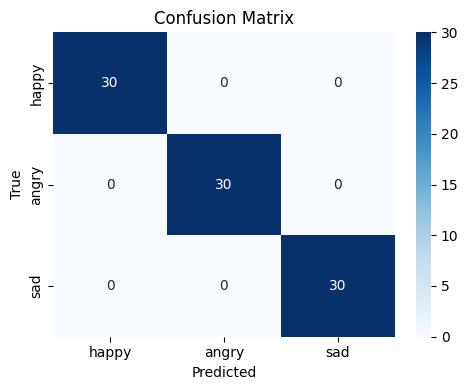

In [61]:
# Compute accuracy and show detailed metrics
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on validation set
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Overall accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Validation accuracy: {acc:.4f}")

# Classification report
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=emotions))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotions, yticklabels=emotions)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from src.features import load_data
from src.model import build_cnn

# Define your emotions (folder names in data/)
emotions = ['happy', 'angry', 'sad']  # Edit as per your dataset

# Load data
X, y = load_data('data', emotions)
X = X[..., np.newaxis]  # Add channel dimension

# Split
test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)

# Build model
input_shape = X_train.shape[1:]
num_classes = len(emotions)
model = build_cnn(input_shape, num_classes)

# Train
model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))

# Save model
model.save('emotion_cnn.h5') 

Epoch 1/30


c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7639 - loss: 21.8008 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9778 - loss: 0.3124 - val_accuracy: 0.9889 - val_loss: 0.1521
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9861 - loss: 0.1312 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9944 - loss: 0.1408 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9972 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9944 - loss: 0.0398 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 4.4897e-04 - val_ac

### Prediction and Inference

This cell defines a helper that loads the saved model and predicts the most likely emotion for a single `.wav` file.

Usage:
- Update `emotions` to the same order used during training.
- Provide a valid Windows-safe path string (use raw strings `r'...'` or forward slashes).
- Example file: `test/happy/OAF_five_happy.wav`.

In [66]:
from tensorflow.keras.models import load_model


emotions = ['happy', 'angry', 'sad']  # Same order as training

def predict_emotion(file_path):
    mfcc = extract_mfcc(file_path)
    mfcc = mfcc[np.newaxis, ..., np.newaxis]  # Add batch and channel dims
    model = load_model('emotion_cnn.h5')
    pred = model.predict(mfcc)
    emotion = emotions[np.argmax(pred)]
    print(f"Predicted emotion: {emotion}")

# Example usage:
predict_emotion('test\happy\OAF_five_happy.wav')


<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
C:\Users\PC\AppData\Local\Temp\ipykernel_19888\2069694242.py:15: SyntaxWarning: invalid escape sequence '\m'
  predict_emotion('test\mixed\OAF_deep_angry.wav')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted emotion: angry
